In [3]:
import pandas as pd

In [4]:
df = pd.read_parquet("train_team_track.parquet", engine='fastparquet')

In [5]:
df.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0


In [6]:
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
corr = df.corr(method='spearman')

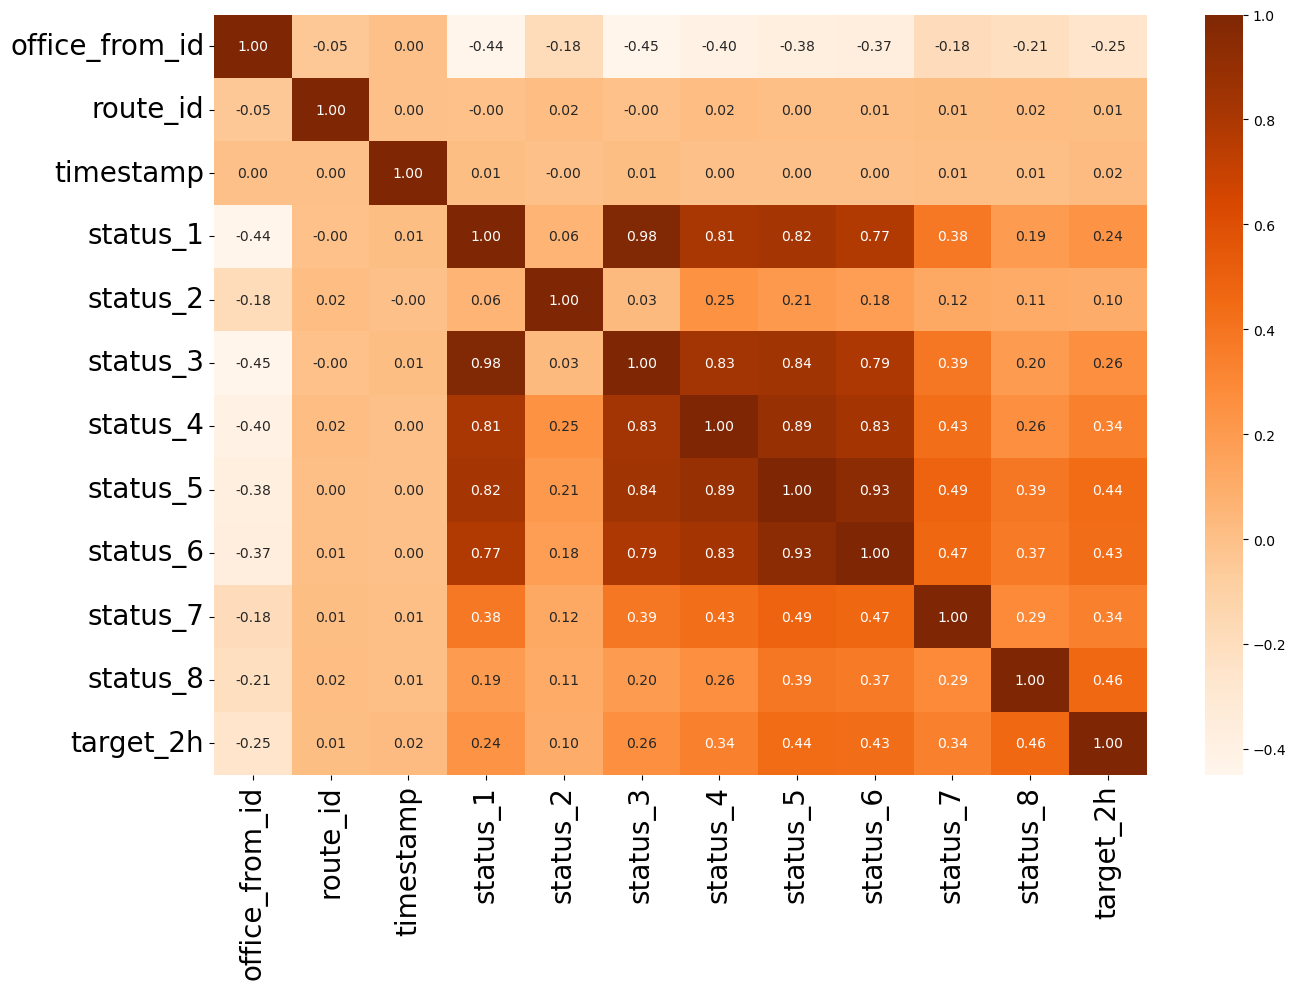

In [8]:
plt.figure(figsize=(14, 10))
ax = sns.heatmap(data=corr, annot=True, cmap='Oranges', fmt='.2f')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
plt.tight_layout()
plt.show()

In [9]:
def density(feature):
    sns.displot(
        {
            'curve-_feature': df[feature]
        },
        kind='kde',
        palette=['orange']
    )
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

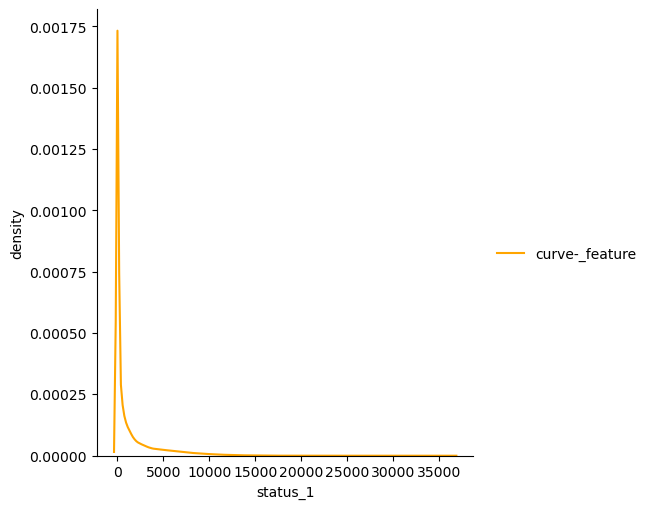

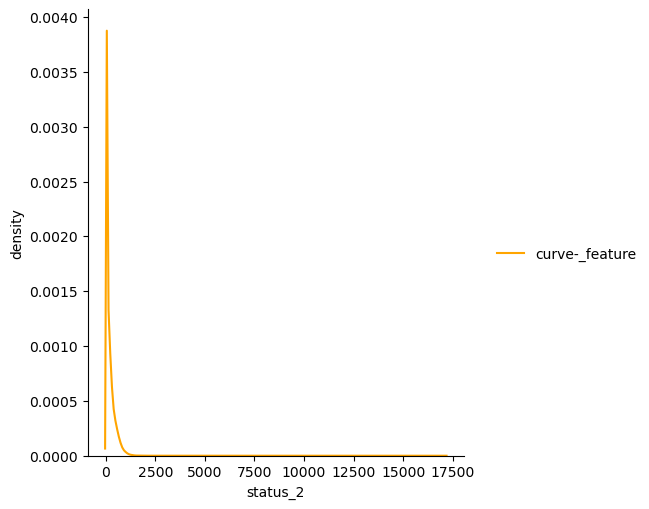

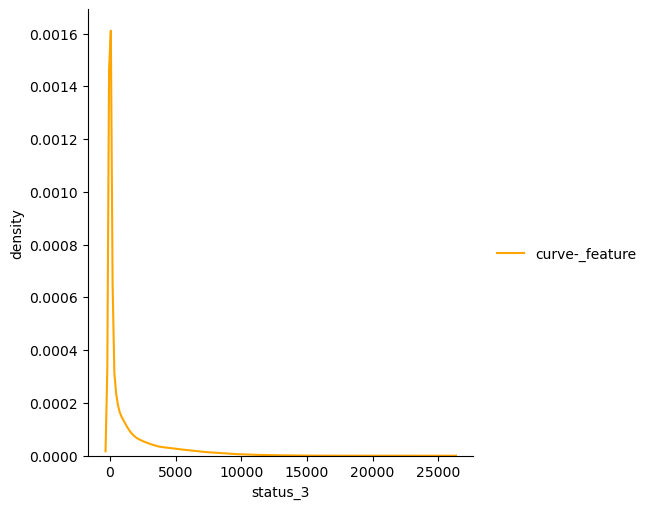

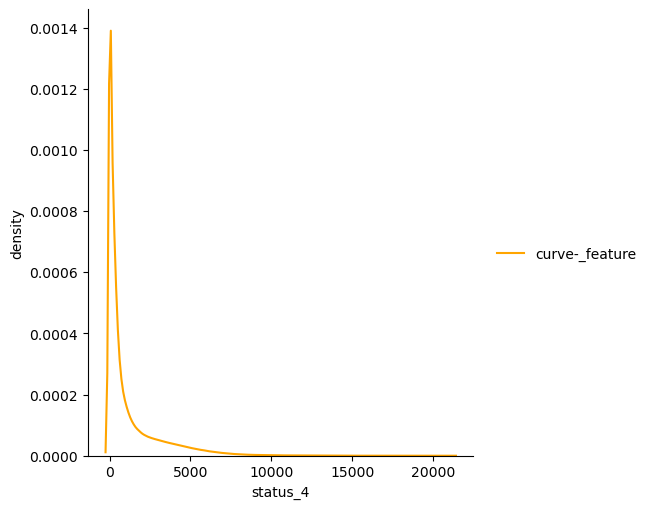

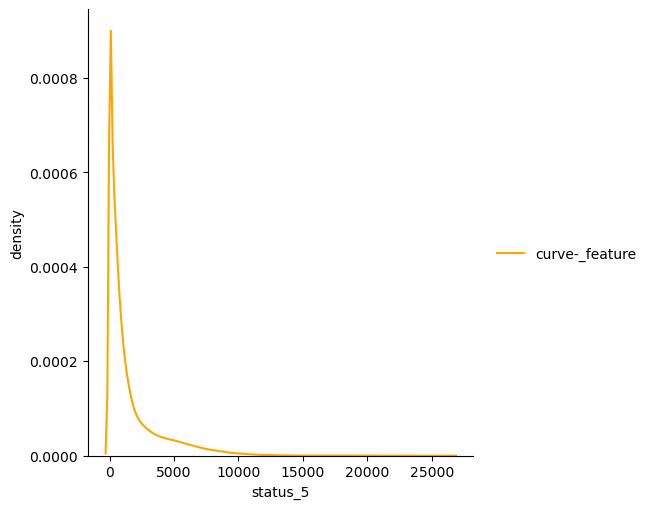

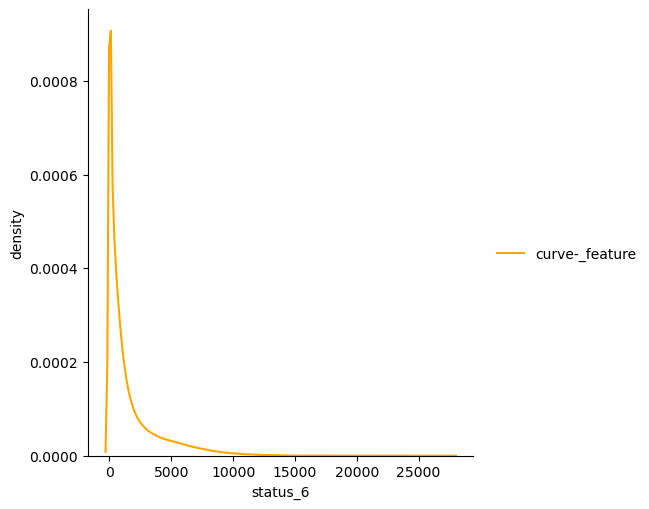

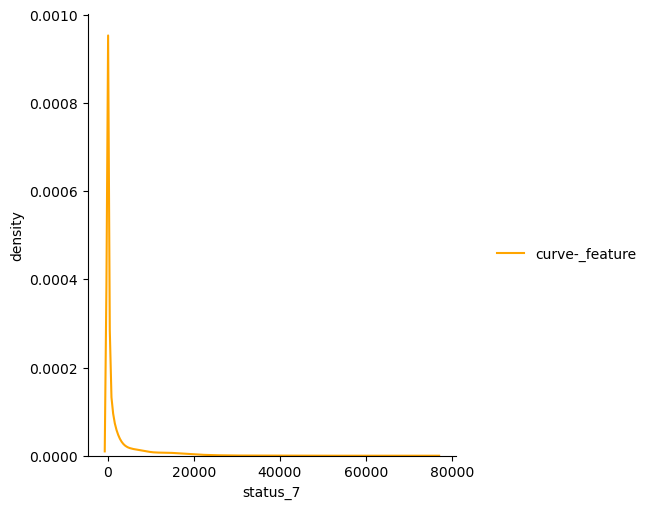

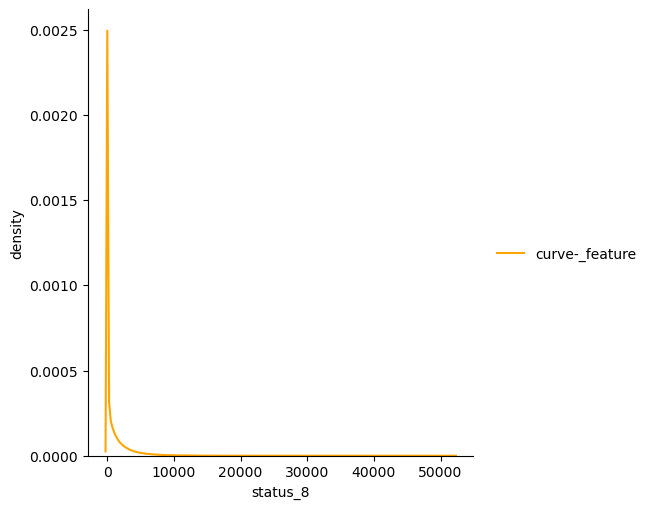

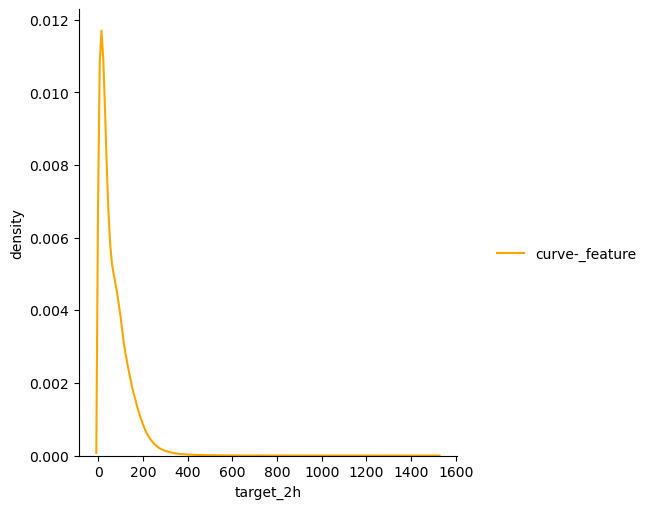

In [19]:
for feature in df.columns[3:]:
    density(feature)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4342000 entries, 0 to 4341999
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   office_from_id  int64         
 1   route_id        int64         
 2   timestamp       datetime64[ns]
 3   status_1        int64         
 4   status_2        int64         
 5   status_3        int64         
 6   status_4        int64         
 7   status_5        int64         
 8   status_6        int64         
 9   status_7        int64         
 10  status_8        int64         
 11  target_2h       float64       
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 397.5 MB


In [31]:
variable_features = df.columns[3:]

In [34]:

df[variable_features].describe()

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
count,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06
mean,1.310749e+03,1.469986e+02,1.278569e+03,1.102996e+03,1.555774e+03,1.555738e+03,2.243071e+03,9.161675e+02,6.874518e+01
std,2.501866e+03,2.066661e+02,2.310502e+03,1.740375e+03,2.194728e+03,2.255213e+03,4.913774e+03,1.872031e+03,6.748811e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.400000e+01,0.000000e+00,6.600000e+01,1.820000e+02,1.100000e+02,0.000000e+00,0.000000e+00,1.900000e+01
50%,1.230000e+02,5.900000e+01,1.440000e+02,3.480000e+02,6.640000e+02,6.410000e+02,2.600000e+01,2.300000e+01,4.800000e+01
75%,1.345000e+03,2.010000e+02,1.463000e+03,1.301000e+03,1.894000e+03,1.944000e+03,1.744000e+03,1.033000e+03,1.000000e+02
max,3.649100e+04,1.715000e+04,2.602000e+04,2.117000e+04,2.656500e+04,2.770200e+04,7.631900e+04,5.203900e+04,1.517000e+03


In [44]:
target = 'target_2h'

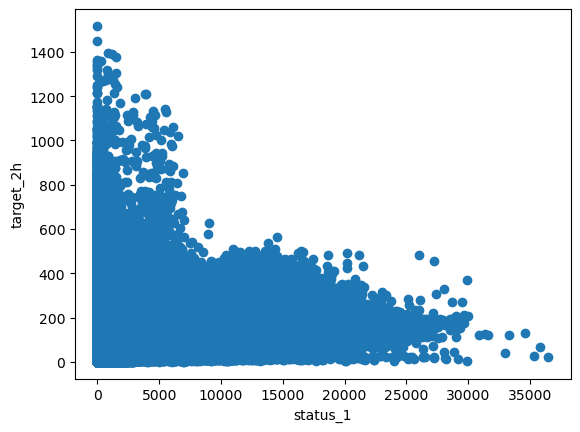

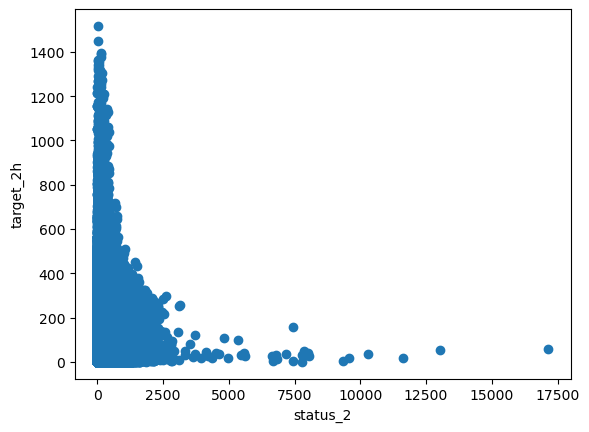

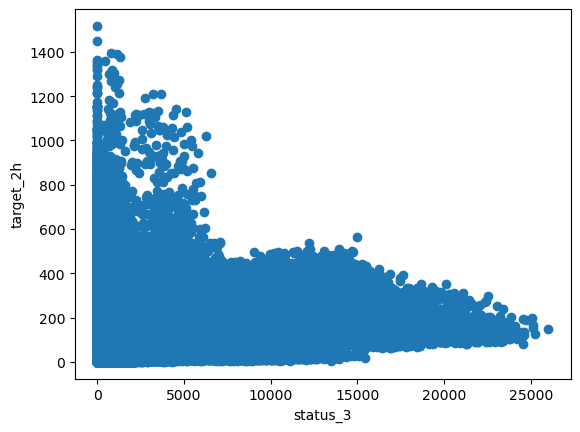

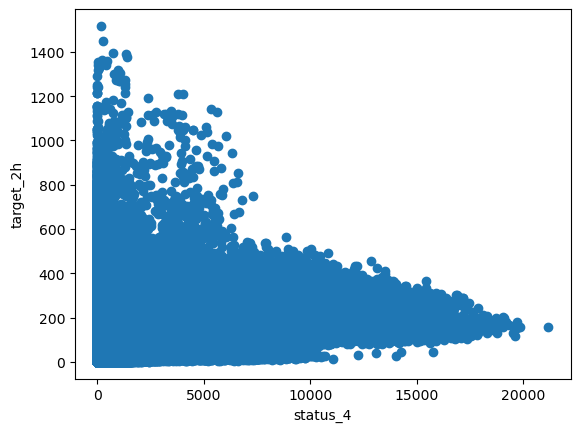

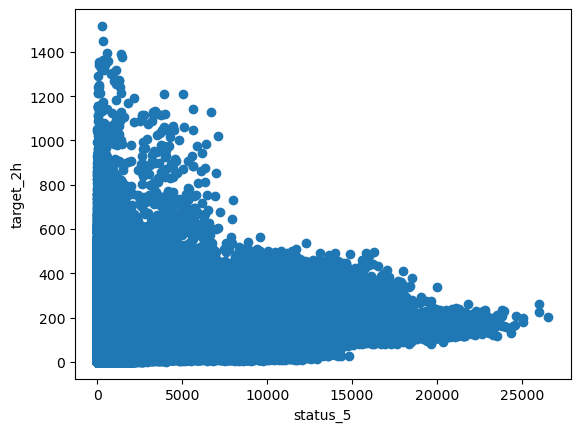

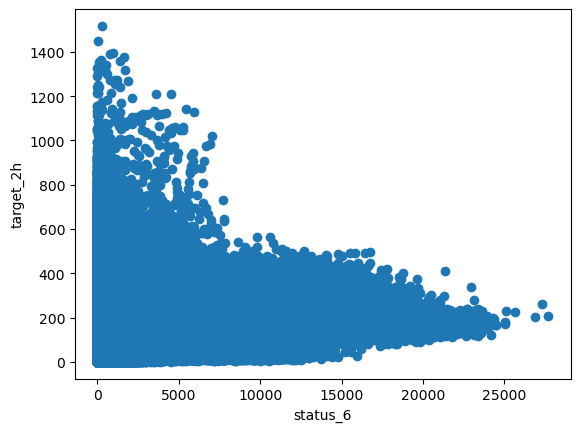

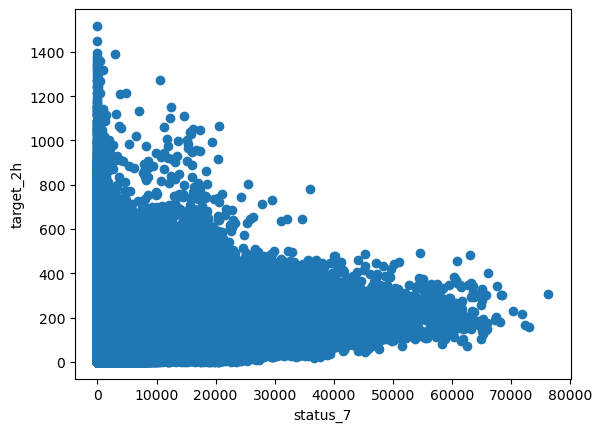

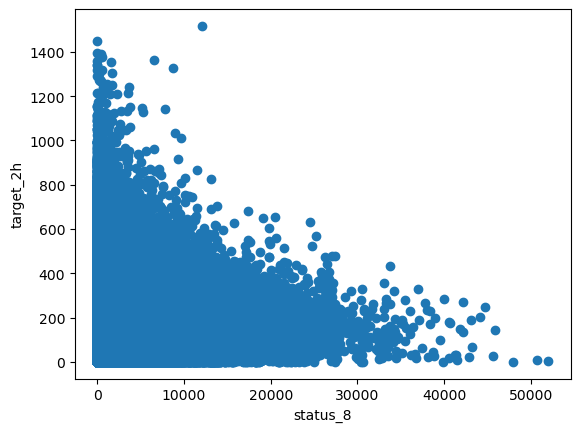

In [47]:
for feature in variable_features[:-1]:
    plt.scatter(df[feature], df[target])
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()